# Configuration set-up and variable settings

In [ ]:
import os
import warnings
import ssl

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization 
from keras.layers import RandomFlip, RandomRotation, RandomZoom, LeakyReLU, GlobalAveragePooling2D
from keras.optimizers import Adam, SGD
from keras.losses import SparseCategoricalCrossentropy
from keras.regularizers import l2 


I0000 00:00:1778176288.493866   70350 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
warnings.filterwarnings("ignore")
ssl._create_default_https_context = ssl._create_unverified_context

# Select TensorFlow's backend
os.environ["KERAS_BACKEND"] = "tensorflow"

# Select hardware accelerator (GPU)
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    details = tf.config.experimental.get_device_details(gpu_devices[0])
    gpu_name = details.get("device_name", "Name not found")
    print(f"Available GPU: {gpu_name}")
else:
    print("No GPU detected.")

print(f"Keras version: {keras.__version__}")

seed = 42
keras.utils.set_random_seed(seed)
np.random.seed(seed)

Available GPU: NVIDIA GeForce GTX 1660 Ti
Keras version: 3.14.0


Some utility function are defined below:

In [3]:
def plot_history(history):
    plt.figure(figsize=(20, 3))
    for i, metric in enumerate(["accuracy", "loss"]):
        plt.subplot(1, 2, i + 1) 
        plt.plot(history.history[metric])
        plt.plot(history.history["val_" + metric])
        plt.title("Model {}".format(metric))
        plt.xlabel("epochs")
        plt.ylabel(metric)
        plt.legend(["train", "val"])


In [4]:
IMG_SHAPE = (256, 256) 
BATCH_SIZE = 32
EPOCHS = 150
METRICS = ["accuracy"]

PATIENCE_STOP = 10
INIT_LR = 1e-3

# Data import and pre-processing

### Data Import

In [5]:
dataset_split = ["train[:80%]", "train[80%:]", "test[:60%]", "test[60%:80%]", "test[80%:]"]
(train_split, val_split, extra_train, extra_val, test_data), info = tfds.load(
    "oxford_iiit_pet", 
    split=dataset_split, 
    as_supervised=True, 
    with_info=True
)

train_split = train_split.concatenate(extra_train)
val_split   = val_split.concatenate(extra_val)

I0000 00:00:1778176290.715591   70350 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4119 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


In [ ]:
labels      = {i: label for i, label in enumerate(info.features["label"].names)}
n_train     = len(np.array([label.numpy() for _, label in train_split]))
n_classes   = info.features["label"].num_classes

In [9]:
input_shape = (IMG_SHAPE[0], IMG_SHAPE[1], 3) # 3 channels for RGB
print(f"Input shape: {input_shape}")

Input shape: (256, 256, 3)


### Pre-processing

In [10]:
def dataset_preprocess(img, label):
    img = tf.image.resize_with_pad(img, IMG_SHAPE[0], IMG_SHAPE[1])
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

def train_preprocess(img, label):
    img = tf.image.resize_with_pad(img, IMG_SHAPE[0], IMG_SHAPE[1])
    img = tf.cast(img, tf.float32) / 255.0

    img = tf.image.random_flip_left_right(img)

    ## Color jittering
    img = tf.image.random_brightness(img, 0.2)      # Range of brightness adjustment [-0.2, 0.2]
    img = tf.image.random_contrast(img, 0.8, 1.2)   # Range of contrast adjustment [0.8, 1.2]
    img = tf.image.random_saturation(img, 0.8, 1.2) # Range of saturation adjustment [0.8, 1.2]
    img = tf.image.random_hue(img, 0.05)            # Range of hue adjustment [-0.05, 0.05]
    
    ## Cropping the image: 
    ## 1. resize it to have a "bigger" image of resize_perc
    ## 2. randomly crop. Output image size is the same of the original
    resize_perc = 1.1 
    new_size = [int(IMG_SHAPE[0] * resize_perc), int(IMG_SHAPE[1] * resize_perc)]
    resized_img = tf.image.resize(img, new_size)
    img = tf.image.random_crop(resized_img, size=[IMG_SHAPE[0], IMG_SHAPE[1], 3])
    
    ## to avoid pixel value overflow after color jittering and cropping (i.e. range [0, 1])
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

In [11]:
## Shuffle all the training set (n_train) and apply data augmentation only to the training set
## use the tf.data.AUTOTUNE to optimize the data loading and preprocessing pipeline by parallelizing the operations
train_ds = train_split.shuffle(n_train).map(train_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)

## Apply the same preprocessing to the validation and test sets, but without data augmentation and shuffling
val_ds   = val_split.map(dataset_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)
test_ds  = test_data.map(dataset_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)


In [12]:
input_shape = (IMG_SHAPE[0], IMG_SHAPE[1], 3) # 3 channels for RGB
print(f"Input shape: {input_shape}")

Input shape: (256, 256, 3)


# 01.02 Model implementation 

In [13]:
k_size = (3, 3)
model = Sequential([
    
    # Input layer
    Input(shape = input_shape),

    # BLOCK 1
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 2
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 3
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 4
    Conv2D(filters = 256, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 256, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Classifier
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dense(units = n_classes, activation = "softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,501 (4.77 MB)

 Trainable params: 1,249,029 (4.76 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [14]:
opt         = SGD(learning_rate = INIT_LR)
loss_fcn    = SparseCategoricalCrossentropy()
model.compile(loss=loss_fcn, optimizer=opt, metrics=METRICS)

callbacks = [
    ## Restore the best weights of the model based on the validation loss, with a patience of EPOCHS epochs
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE_STOP, restore_best_weights=True, verbose=1),
]

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=callbacks);  

Epoch 1/150


I0000 00:00:1778176299.833256   70521 service.cc:153] XLA service 0x77d8e8034c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778176299.833355   70521 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1778176299.958035   70521 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778176300.183929   70521 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1778176300.205060   70521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17930__.82
E0000 00:00:1778176303.250845   70521 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778176308.559370   70521 cuda_timer.cc:87] Delay kernel timed out: me

160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.0336 - loss: 3.9497

I0000 00:00:1778176354.246361   70520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17930__.82
E0000 00:00:1778176355.550804   70520 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778176358.080885   70520 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778176365.858154   70520 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


161/161 ━━━━━━━━━━━━━━━━━━━━ 87s 401ms/step - accuracy: 0.0397 - loss: 3.7910 - val_accuracy: 0.0231 - val_loss: 3.8170
Epoch 2/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 229ms/step - accuracy: 0.0639 - loss: 3.5731 - val_accuracy: 0.0279 - val_loss: 4.2168
Epoch 3/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.0842 - loss: 3.4857 - val_accuracy: 0.0415 - val_loss: 4.1843
Epoch 4/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 232ms/step - accuracy: 0.0898 - loss: 3.4174 - val_accuracy: 0.0517 - val_loss: 4.0199
Epoch 5/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.0970 - loss: 3.3498 - val_accuracy: 0.0755 - val_loss: 3.7202
Epoch 6/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.1123 - loss: 3.3115 - val_accuracy: 0.0687 - val_loss: 3.5723
Epoch 7/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.1250 - loss: 3.2544 - val_accuracy: 0.0660 - val_loss: 3.7981
Epoch 8/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.1259 - loss: 3.219

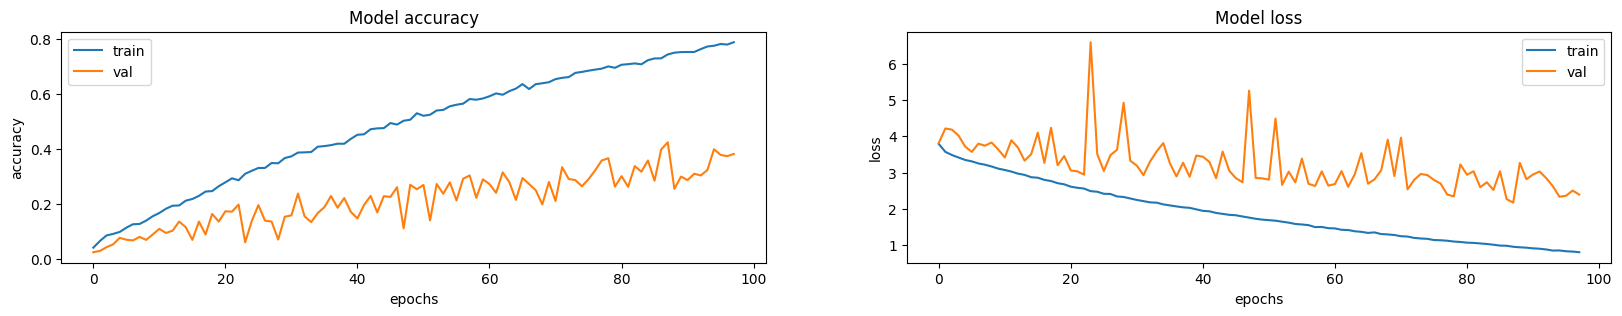

In [15]:
plot_history(history)

In [16]:
test_loss, test_metric = model.evaluate(test_ds, verbose=0)
pred = model.predict(test_ds, verbose=0)

print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")
print("Test output shape: {}".format(pred.shape))

The test loss is 2.2664, the test accuracy is 0.4128.
Test output shape: (734, 37)
